# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**: all ETL steps from folder `/datasets_ETL`
* **The purpose of this Notebook**:
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/)
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel)
* **Input**: `/preprocess_dataset`, containing the `*.npz` files created in ETL steps splitted in train, val and test.
* **Output:**
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`

# Imports

In [1]:
!pip install huggingface_hub

In [2]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import HfApi, login
from huggingface_hub.utils import disable_progress_bars
from scipy.stats import entropy

In [3]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data/process_dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Definition of frequencies and bands

According to [AASM](https://aasm.org/)

| Wave | Frequency | Obs|
| --- | ---| --- |
| Delta | [0.5, 4] | N3 |
| Theta | [4, 8] | N1 |
| Alpha | [8, 13] | Wake, with eyes close |
| Sigma | [11, 16] | N2, Sleep spindle |
| Beta | [16, 30] | Wake |

In [4]:
# Set the sampling frequency, 100 Hz
SFREQ = 100

# We define the bands according to the AASM clinical table
EEG_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Sigma': (11, 16),    # Sleep spindles
    'Beta': (16, 30)
}

# Feature extraction


| Feature Name (Column) | What it represents|
| --- | --- |
| **Mean** | The general baseline of the wave. |
| **Std** | The overall "height" of the waves. |
| **Skewness** | If the wave leans more towards positive or negative values. |
| **Kurtosis** | High values mean there are sudden spikes, glitches, or movement artifacts. |
| **Zero_Crossings** | Fast waves cross Ox often. |
| **Abs_val** | The raw mathematical energy of brainwaves. |
| **Abs_Total** | The combined total energy of all the frequency bands mentioned above. |
| **Rel_val** | The *percentage* of the total energy that belongs to a wave. |
| **Label** | 0 = Wake, 1 = N1, 2 = N2, 3 = N3, 4 = REM. |

In [5]:
def extract_features(epoch):
    '''
    Extract features from an epoch of EEG data.

    Parameters:
      - epoch (numpy.ndarray): The EEG data for a single epoch.

    Returns:
      - list: A list of extracted features.
    '''
    features = []

    # --- 1. TIME DOMAIN ---
    features.append(np.mean(epoch))            # Mean
    features.append(np.std(epoch))             # Std
    features.append(skew(epoch))               # Skewness
    features.append(kurtosis(epoch))           # Kurtosis

    # Zero-crossing rate
    zero_crosses = np.nonzero(np.diff(epoch > 0))[0]
    features.append(len(zero_crosses))

    # HJORTH PARAMETERS
    # Calculate the first derivative (the difference between consecutive points) and the second
    dx = np.diff(epoch)
    ddx = np.diff(dx)

    # Calculate the variance for the signal and its derivatives
    var_x = np.var(epoch)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)

    # Mobility: Measures the proportion of high frequencies (how "shakey" the signal is)
    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0
    features.append(mobility)

    # Complexity: Measures the deviation of the signal from a perfect (sine) wave
    mobility_dx = np.sqrt(var_ddx / var_dx) if var_dx > 0 else 0
    complexity = mobility_dx / mobility if mobility > 0 else 0
    features.append(complexity)

    # --- 2. FREQUENCY DOMAIN ---
    freqs, psd = welch(epoch, SFREQ, nperseg=SFREQ*2)

    # SPECTRAL ENTROPY
    # Transform the PSD into a probability distribution and calculate the chaos
    psd_norm = psd / np.sum(psd)
    spec_entropy = entropy(psd_norm)
    features.append(spec_entropy)

    # Calculate the absolute power for each band
    for band, (fmin, fmax) in EEG_BANDS.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_power = np.sum(psd[idx_band])
        features.append(band_power)

    # Total signal strength
    total_power = np.sum(psd)
    features.append(total_power)

    # Calculate the relative power for each band
    for band, (fmin, fmax) in EEG_BANDS.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_power = np.sum(psd[idx_band])
        relative_power = band_power / total_power if total_power > 0 else 0
        features.append(relative_power)

    return features

In [6]:
def process_folder(folder_path, output_csv):
    '''
    Process all files in a folder and save the extracted features to a CSV file.

    Parameters:
      - folder_path (str): Path to the folder containing the data files.
      - output_csv (str): Path to the CSV file where the extracted features will be saved.
    '''
    if os.path.exists(output_csv):
        print(f"File {output_csv} already exist.")
        return

    files = glob.glob(os.path.join(folder_path, "*.npz"))

    if not files:
        print(f"No data found {folder_path}")
        return

    print(f"Process {len(files)} files from {folder_path}...")

    all_features = []
    all_labels = []
    all_subject_ids = []
    all_dataset_sources = []

    for subject_id, f in enumerate(files, start=1):
        filename = os.path.basename(f).lower()

        if 'ucd' in filename:
            dataset_source = 1  # C3-A2
        elif 'hmc' in filename:
            dataset_source = 2  # C4-M1
        else:
            dataset_source = 0  # Fpz-Cz

        with np.load(f) as data:
            X = data['x']  # Shape: (number_epochs, 3000, 1)
            y = data['y']  # Shape: (number_epochs,)

        # Transform X into 2D: (nr_epochs, nr_samples)
        X = X.reshape(X.shape[0], -1)

        # Extract the features from era to era
        for i in range(X.shape[0]):
            feats = extract_features(X[i])
            all_features.append(feats)                 # fatures
            all_labels.append(y[i])                    # labels
            all_subject_ids.append(subject_id)         # subject_id
            all_dataset_sources.append(dataset_source) # datasources

    # Define column names
    col_names = ['Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
        'Mobility', 'Complexity', 'Spectral_Entropy',
        'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
        'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
    ]

    df = pd.DataFrame(all_features, columns=col_names)

    df['Subject_ID'] = all_subject_ids
    df['Dataset_Source'] = all_dataset_sources
    df['Label'] = all_labels

    cols = ['Subject_ID', 'Dataset_Source'] + col_names + ['Label']
    df = df[cols]

    df.to_csv(output_csv, index=False)
    print(f"Saved! Table size: {df.shape} -> {output_csv}\n")

In [9]:
folders = ['train','val','test']
for folder in folders:
  process_folder(base_path + '/' + folder,
                 base_path + '/ml_dataset/' + folder + '_features.csv')

File /content/drive/MyDrive/sleep_data/process_dataset/ml_dataset/train_features.csv already exist.
File /content/drive/MyDrive/sleep_data/process_dataset/ml_dataset/val_features.csv already exist.
File /content/drive/MyDrive/sleep_data/process_dataset/ml_dataset/test_features.csv already exist.


# Sanity Check

In [10]:
df = pd.read_csv(base_path+'/ml_dataset/train_features.csv')

print("=== Technical check ===")
print(f"Table shape: {df.shape} (Rows: epochs, Columns: features)")

# Check if there are missing or infinite values
nan_count = df.isna().sum().sum()
inf_count = np.isinf(df.drop('Label', axis=1)).sum().sum()
print(f"Missing values ​​(NaN): {nan_count}")
print(f"Infinite values ​​(Inf): {inf_count}")

# If we have NaNs, we replace them with 0 so that the model doesn't break later.
if nan_count > 0 or inf_count > 0:
    print("Warning: Cleaning NaN/Inf values...")
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

=== Technical check ===
Table shape: (228213, 22) (Rows: epochs, Columns: features)
Missing values ​​(NaN): 0
Infinite values ​​(Inf): 0


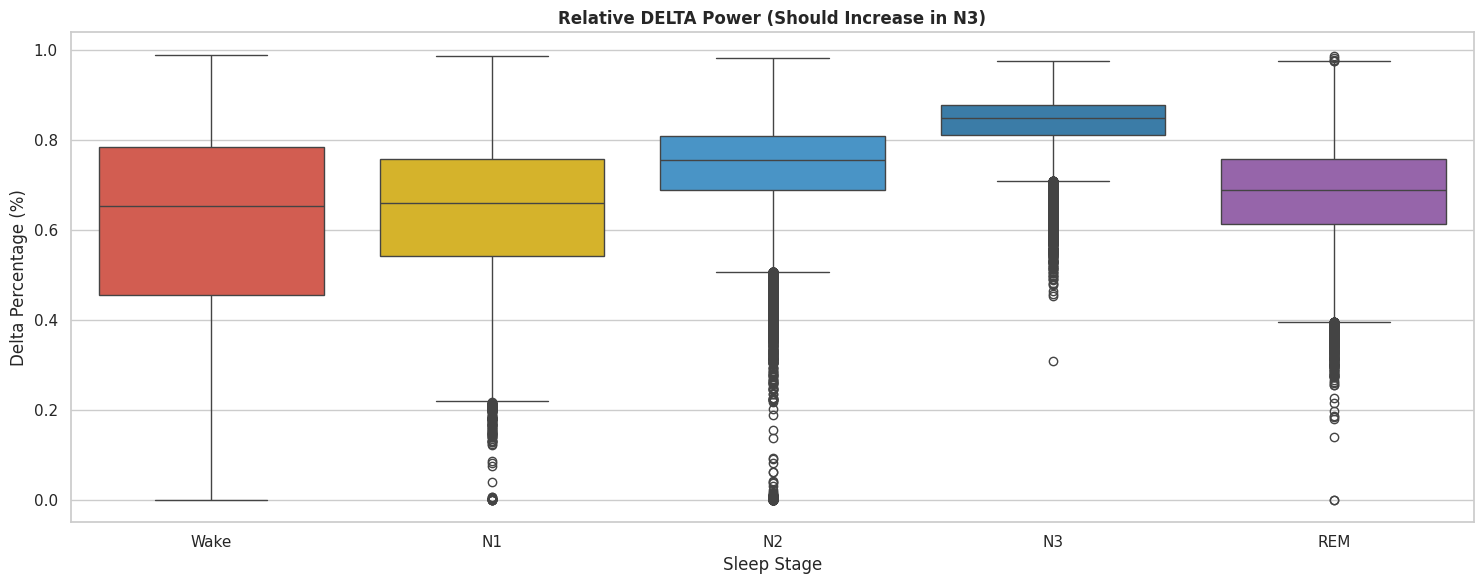

In [11]:
# Map the numeric labels to names for the chart
stage_mapping = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
df['Stage_Name'] = df['Label'].map(stage_mapping)

# Set the graphics style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 1, figsize=(15, 6))
palette = ['#e74c3c', '#f1c40f', '#3498db', '#2980b9', '#9b59b6'] # Culorile tale

sns.boxplot(x='Stage_Name', y='Rel_Delta', data=df, ax=axes, palette=palette, hue='Stage_Name', legend=False, order=['Wake', 'N1', 'N2', 'N3', 'REM'])
axes.set_title('Relative DELTA Power (Should Increase in N3)', fontweight='bold')
axes.set_xlabel('Sleep Stage')
axes.set_ylabel('Delta Percentage (%)')

plt.tight_layout()
plt.show()

Graphical interpretation:
* The **line in the middle** of each box is the **median**.
* In stage **N3, approximately 85%** of brain activity is **Delta** waves
* Stages N1, N2 and REM: Have a much lower presence of Delta waves, which is normal.
* Wake (Red Box): Has a very high variation. **Eye movements, blinking and facial muscles introduce noise**, artifacts, into the EEG signal that, spectrally, frequently overlap with the Delta band.

In [12]:
display(df.describe())

,Subject_ID,Dataset_Source,Mean,Std,Skewness,Kurtosis,Zero_Crossings,Mobility,Complexity,Spectral_Entropy,...,Abs_Alpha,Abs_Sigma,Abs_Beta,Abs_Total,Rel_Delta,Rel_Theta,Rel_Alpha,Rel_Sigma,Rel_Beta,Label
count,228213.000000,228213.000000,228213.000000,2.282130e+05,228213.000000,228213.000000,228213.000000,228213.000000,228213.000000,228213.000000,...,2.282130e+05,2.282130e+05,2.282130e+05,2.282130e+05,2.282130e+05,2.282130e+05,2.282130e+05,2.282130e+05,2.282130e+05,228213.000000
mean,123.772953,0.784451,0.004092,1.419280e+04,-0.068328,3.308196,725.962894,0.352241,3.710663,2.682281,...,4.138898e+08,2.195055e+08,2.230821e+08,7.023707e+09,7.059229e-01,1.212771e-01,7.772596e-02,4.658869e-02,4.296118e-02,1.912192
std,74.597349,0.944687,1274.922932,6.477981e+04,0.693118,16.058245,346.516118,0.174195,1.860278,0.566951,...,2.344186e+09,1.445264e+09,2.162365e+09,4.961993e+10,1.495893e-01,7.274496e-02,7.012425e-02,3.903816e-02,5.401849e-02,1.307862
min,1.000000,0.000000,-64047.175483,1.425380e-17,-42.732337,-2.000000,0.000000,0.027187,1.000000,0.636514,...,4.035597e-35,3.942157e-35,2.292689e-35,3.072877e-34,1.147948e-13,1.326097e-13,1.749805e-13,1.886738e-13,7.768905e-13,0.000000
25%,60.000000,0.000000,-0.100203,1.039629e+01,-0.257880,0.738852,512.000000,0.234908,2.614426,2.299473,...,1.138893e+01,6.491723e+00,3.954493e+00,1.906182e+02,6.353828e-01,6.935694e-02,3.176662e-02,1.848581e-02,9.973562e-03,1.000000
50%,119.000000,0.000000,-0.000196,1.463105e+01,-0.030911,1.735456,668.000000,0.320581,3.286279,2.704374,...,2.319395e+01,1.448311e+01,8.546489e+00,3.794622e+02,7.404318e-01,1.112919e-01,5.881644e-02,3.576103e-02,2.342603e-02,2.000000
75%,186.000000,2.000000,0.100148,2.284877e+01,0.156532,3.757933,861.000000,0.428205,4.271225,3.064878,...,4.782944e+01,3.081342e+01,2.242383e+01,9.231447e+02,8.145565e-01,1.594377e-01,9.949841e-02,6.338006e-02,5.391701e-02,3.000000
max,259.000000,2.000000,49148.284986,1.662543e+06,57.036444,3938.562741,5999.000000,2.000005,46.430557,4.370763,...,4.442120e+11,2.979627e+11,3.634847e+11,3.727632e+12,9.892882e-01,9.828897e-01,6.744965e-01,4.364566e-01,8.465086e-01,4.000000


# Upload Hugging Face

In [13]:
repo_id = 'carmentheodora/Sleep_Quality_Dataset_Clean'

In [14]:
disable_progress_bars()

hf_token = os.environ.get("HF_TOKEN", hf_token)

base_dir = base_path + '/ml_dataset/'

api = HfApi()

print(f"Uploading '{base_dir}'...")

try:
    api.upload_folder(
        folder_path=base_dir,
        path_in_repo="ml_dataset",
        repo_id=repo_id,
        repo_type="dataset",
        token=hf_token
    )
    print("Done upload in Hugging Face!")
except Exception as e:
    print(f"Error: {e}")

Uploading '/content/drive/MyDrive/sleep_data/process_dataset/ml_dataset/'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Done upload in Hugging Face!
